In [12]:
# ==========================================
# PHASE 1: DATA LOADING & INITIAL INSPECTION
# ==========================================

# STEP 1: Import required libraries
import pandas as pd  # Pandas is our primary tool for data manipulation and analysis
import os            # OS allows us to interact with the computer's file system safely

# STEP 2: Define a robust, relative file path
# We use os.path.join so this code works on both Windows (\) and Mac/Linux (/) without breaking.
file_path = os.path.join("data", "raw", "digital_marketing_campaign_dataset.csv")

# STEP 3: Implement Error Handling (Try/Except block)
# We wrap our code in a 'try' block. If the file is missing, it won't crash the whole notebook.
try:
    # STEP 3A: Load the dataset into a Pandas DataFrame ('df')
    df = pd.read_csv(file_path)
    
    # STEP 4: Inspect the structure of the dataset
    # df.info() tells us the number of rows, columns, data types, and if any data is missing (nulls).
    print("--- Dataset Info ---")
    df.info()
    
    # STEP 5: Calculate the Baseline Conversion Metrics
    # This is critical for ROAS. We need to know how many people actually converted.
    print("\n--- Baseline Conversion Metrics ---")
    
    # Count the raw number of 1s (Converted) and 0s (Not Converted)
    conversion_counts = df['Conversion'].value_counts(dropna=False)
    
    # Calculate the percentage by using normalize=True, then multiply by 100
    conversion_rates = df['Conversion'].value_counts(normalize=True, dropna=False) * 100
    
    # STEP 6: Combine the raw counts and percentages into a clean, readable table
    baseline_metrics = pd.DataFrame({
        'Total Count': conversion_counts,
        'Percentage (%)': conversion_rates
    })
    
    # Display the final table to the screen
    print(baseline_metrics)

# STEP 7: The 'Except' block triggers ONLY if the file was not found in Step 3A.
except FileNotFoundError:
    print(f"ERROR: Could not find the dataset at '{file_path}'.")
    # os.getcwd() tells the user exactly where the notebook is currently looking, helping them fix it.
    print(f"DIAGNOSTIC: Your current Jupyter working directory is: {os.getcwd()}")
    print("ACTION: Please verify your directory structure and update the 'file_path' variable.")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases

C:\Users\Rimi\AppData\Local\Temp\ipykernel_2964\3049940585.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Conversion', y='Income', ax=axes[1], palette='Set2')


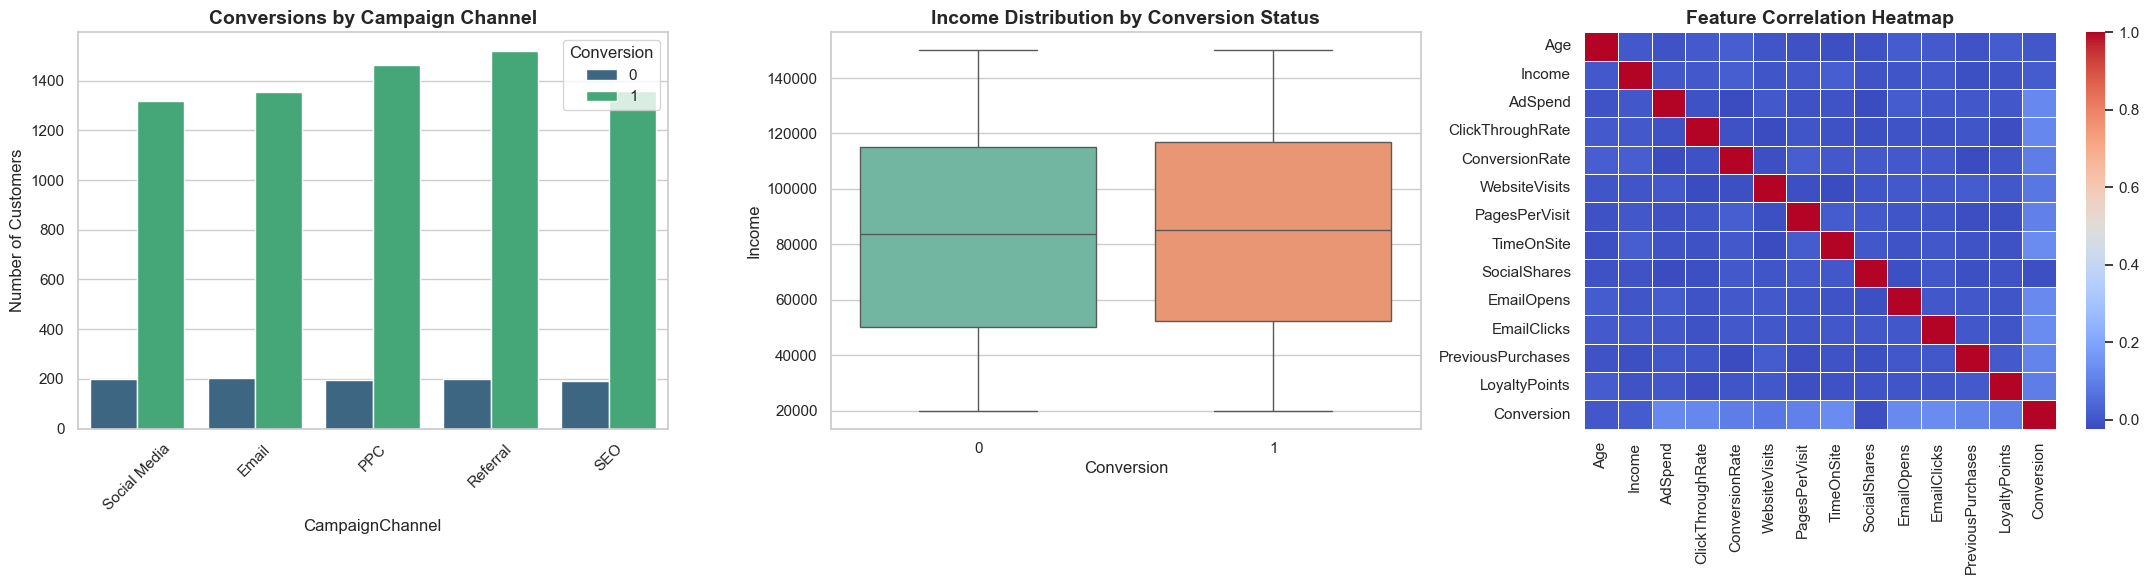

In [13]:
# ==========================================
# PHASE 1B: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# STEP 1: Import all required libraries
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 2: Load the dataset securely (THIS FIXES THE 'df' ERROR)
# We ensure the notebook actually has the data in its memory before drawing charts.
file_path = os.path.join("data", "raw", "digital_marketing_campaign_dataset.csv")
df = pd.read_csv(file_path)

# STEP 3: Set the aesthetic style for professional business reports
sns.set_theme(style="whitegrid")

# STEP 4: Create a canvas (figure) with 3 side-by-side charts
# figsize=(22, 6) makes the canvas wide enough to fit all three comfortably
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ---------------------------------------------------------
# CHART 1: Categorical Analysis (Campaign Channel vs. Conversion)
# WHY: We need to see which marketing channels yield the highest volume of conversions. 
# This directly informs where we should allocate our Ad Spend.
# ---------------------------------------------------------
sns.countplot(data=df, x='CampaignChannel', hue='Conversion', ax=axes[0], palette='viridis')
axes[0].set_title('Conversions by Campaign Channel', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=45) # Rotate labels so they don't overlap

# ---------------------------------------------------------
# CHART 2: Numeric Distribution (Income by Conversion Status)
# WHY: Does a customer's income dictate if they convert? Boxplots show us the median 
# and spread of income for converters (1) vs. non-converters (0).
# ---------------------------------------------------------
sns.boxplot(data=df, x='Conversion', y='Income', ax=axes[1], palette='Set2')
axes[1].set_title('Income Distribution by Conversion Status', fontsize=14, fontweight='bold')

# ---------------------------------------------------------
# CHART 3: Multicollinearity Check (Feature Correlation Heatmap)
# WHY: Machine Learning models get confused by redundant data. We use a heatmap to 
# find features that are essentially measuring the exact same thing (dark red squares).
# ---------------------------------------------------------
# Drop 'CustomerID' first, as it is just a random ID and adds no predictive value
numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop('CustomerID', axis=1)

# Calculate the Pearson correlation matrix
corr_matrix = numeric_cols.corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', ax=axes[2], linewidths=0.5)
axes[2].set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

# STEP 5: Adjust layout and display the charts
plt.tight_layout()
plt.show()

In [14]:
# ==========================================
# PHASE 2: FEATURE ENGINEERING
# ==========================================

# STEP 1: Import required libraries
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler

# STEP 2: Reload the dataset (Safeguard against 'df is not defined' memory errors)
file_path = os.path.join("data", "raw", "digital_marketing_campaign_dataset.csv")
df = pd.read_csv(file_path)

# STEP 3: Drop Non-Predictive and Confidential Columns
# WHY: 'CustomerID' is a random number. The 'Confidential' columns add no mathematical value.
columns_to_drop = ['CustomerID', 'AdvertisingPlatform', 'AdvertisingTool']
df_cleaned = df.drop(columns=columns_to_drop)

# STEP 4: Separate the Features (X) from the Target (y)
# 'X' is everything we use to predict. 'y' is what we are trying to predict (Conversion).
X = df_cleaned.drop('Conversion', axis=1)
y = df_cleaned['Conversion']

# STEP 5: Categorical Encoding (One-Hot Encoding)
# WHY: Machine Learning models only understand numbers, not words.
# pd.get_dummies converts these text categories into binary (0 or 1) columns.
# drop_first=True prevents perfect multicollinearity (the Dummy Variable Trap).
categorical_cols = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# STEP 6: Feature Scaling (Standardization)
# WHY: We don't want a large number like Income to overpower a small number like Age.
# StandardScaler transforms numeric columns so they are mathematically on the same scale.
numeric_columns = X_encoded.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()

X_scaled = X_encoded.copy()
X_scaled[numeric_columns] = scaler.fit_transform(X_encoded[numeric_columns])

# STEP 7: Verification Output
print("✅ Feature Engineering Complete!")
print(f"Original Feature Shape (Before Encoding): {X.shape}")
print(f"Engineered Feature Shape (After Encoding): {X_scaled.shape}")
print("\n--- First 3 Rows of Engineered Data (X_scaled) ---")
print(X_scaled.head(3))

✅ Feature Engineering Complete!
Original Feature Shape (Before Encoding): (8000, 16)
Engineered Feature Shape (After Encoding): (8000, 21)

--- First 3 Rows of Engineered Data (X_scaled) ---
        Age    Income   AdSpend  ClickThroughRate  ConversionRate  \
0  0.830400  1.390381  0.527484         -1.320328       -0.298084   
1  1.702775 -1.141736 -0.388418          0.010671        1.427538   
2  0.159343  0.100905 -1.217296          1.460225       -0.509632   

   WebsiteVisits  PagesPerVisit  TimeOnSite  SocialShares  EmailOpens  ...  \
0      -1.729507      -1.208303   -0.078268     -1.065759   -0.608829  ...   
1       1.205221      -1.009576   -0.561778     -1.550199   -1.309262  ...   
2      -1.589758       1.025746    1.435016     -1.723213    0.266712  ...   

   PreviousPurchases  LoyaltyPoints  Gender_Male  CampaignChannel_PPC  \
0          -0.168115      -1.260823        False                False   
1          -0.860656       0.677701         True                False   


In [15]:
# ==========================================
# PHASE 3: MODEL SELECTION & TRAINING
# ==========================================

# STEP 1: Import Machine Learning and Evaluation Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# STEP 2: Train/Test Split (80% Training, 20% Testing)
# stratify=y ensures our 87% conversion ratio is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape:  {X_test.shape}\n")

# STEP 3: Initialize the Models
# Logistic Regression (Our Baseline)
log_reg = LogisticRegression(random_state=42)

# Random Forest (Our Advanced Ensemble Model)
# class_weight='balanced' forces the model to pay extra attention to the 13% Non-Converters
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# STEP 4: Train (Fit) the Models on the 80% Training Data
print("Training AI Models... (This might take a few seconds)")
log_reg.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
print("✅ Models Successfully Trained!\n")

# STEP 5: Make Predictions on the 20% 'Hidden' Test Data
y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# STEP 6: Quick Performance Check (Using F1-Score)
print("--- Initial Performance Check (F1-Score) ---")
print(f"Logistic Regression F1: {f1_score(y_test, y_pred_log):.4f}")
print(f"Random Forest F1:       {f1_score(y_test, y_pred_rf):.4f}")

Training Data Shape: (6400, 21)
Testing Data Shape:  (1600, 21)

Training AI Models... (This might take a few seconds)
✅ Models Successfully Trained!

--- Initial Performance Check (F1-Score) ---
Logistic Regression F1: 0.9412
Random Forest F1:       0.9370


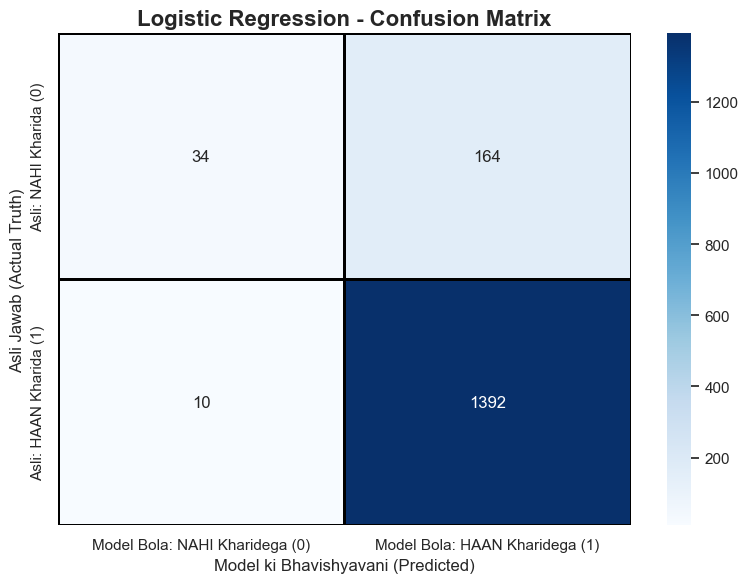


--- Detailed Business Report (Classification Report) ---
              precision    recall  f1-score   support

           0       0.77      0.17      0.28       198
           1       0.89      0.99      0.94      1402

    accuracy                           0.89      1600
   macro avg       0.83      0.58      0.61      1600
weighted avg       0.88      0.89      0.86      1600



In [ ]:
# ==========================================
# PHASE 4: PERFORMANCE EVALUATION (ROAS METRICS)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("GENERATING CONFUSION MATRIX FOR WINNING MODEL...")

# We select Logistic Regression as our champion model based on the higher F1-score
# Step 1: Generate the Confusion Matrix
# y_test = The actual ground truth (Did the customer actually convert?)
# y_pred_log = The model's prediction
cm = confusion_matrix(y_test, y_pred_log)

# Step 2: Visualize the Confusion Matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black')

plt.title('Logistic Regression - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Truth (Did they buy?)', fontsize=12)
plt.xlabel('AI Prediction', fontsize=12)

# Custom labels for clear business reporting to stakeholders
plt.xticks([0.5, 1.5], ['Predicted: Will NOT Buy (0)', 'Predicted: WILL Buy (1)'])
plt.yticks([0.5, 1.5], ['Actual: Did NOT Buy (0)', 'Actual: DID Buy (1)'], va='center')

plt.tight_layout()
plt.show()

# Step 3: Print the Detailed Classification Report (Precision, Recall, F1)
print("\n--- Detailed Business Report (Classification Report) ---")
print(classification_report(y_test, y_pred_log))